In [33]:
import os
from dotenv import load_dotenv

load_dotenv(override=True)

True

In [34]:
os.environ["OLLAMA_MODEL"] = os.getenv("OLLAMA_MODEL", "Gemma4")
os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY", "")

In [35]:
import json
from tavily import TavilyClient
from typing import Literal

tavily_client = TavilyClient(api_key=os.environ["TAVILY_API_KEY"])

def web_search(query: str, max_results: int = 5,topic: Literal["general", "news", "sports", "finance", "technology"] = "general", include_rew_content: bool = False) -> str:
    """
    Perform a web search using Tavily API.

    Args:
        query (str): The search query.
        max_results (int): Maximum number of results to return. Default is 5.
        topic (Literal): The topic of the search. Default is "general".
        include_rew_content (bool): Whether to include rewritten content in the results. Default is False.

    Returns:
        list: A list of search results.
    """
    response = tavily_client.search(
        query=query, 
        max_results=max_results, 
        topic=topic, 
        include_rew_content=include_rew_content
    )
    return json.dumps(response.get("results", []), ensure_ascii=False)

In [36]:
from langchain.chat_models import init_chat_model

model = init_chat_model("ollama:"+os.environ["OLLAMA_MODEL"])
model

ChatOllama(metadata={'lc_versions': {'langchain-core': '1.6.1', 'langchain': '1.4.0'}}, model='Gemma4')

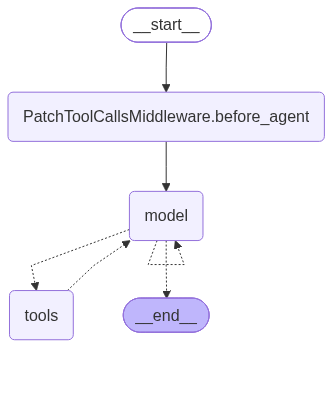

In [37]:
### Create a deep agent that uses the web_search function to perform searches and return results. The agent should be able to take a query as input and return the top search results.
from deepagents import create_deep_agent

deep_agent = create_deep_agent(
    model=model,
    tools=[web_search],
    system_prompt="You are a web search agent that can perform searches using the Tavily API.",
)
deep_agent

In [ ]:
result = deep_agent.invoke({"messages": [{"role": "user", "content": "What is langgraph?"}]})

# Print the agent's response
print(result["messages"][-2].content)

Hello! I am ready to assist you. Please let me know what you need help with, or what task you would like me to perform.


In [41]:
print(response["messages"][-1].content)
